Imports


In [50]:
import spacy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
import re
from sklearn.model_selection import train_test_split

EDA


In [51]:
df = pd.read_csv('Group20_RawData.csv')
df.head()

,id,title,link,content,gold_label
0,0,نیٹ فلکس ڈاؤن، سوشل میڈیا پر شکایتوں کا طوفان ...,https://www.express.pk/story/2733439/netflix-d...,معروف امریکی اسٹریمنگ پلیٹ فارم نیٹ فلکس باکسن...,entertainment
1,1,پاکستانی ویب سیریز ’فروٹ چاٹ‘ کی شوٹنگ کا آغا...,https://www.express.pk/story/2733408/the-shoot...,عالمی ایوارڈ یافتہ پاکستان شوبز کے نوجوان ہدای...,entertainment
2,2,ریاض میں رنگارنگ فیشن شو، جینیفر لوپیز سمیت دی...,https://www.express.pk/story/2733380/a-colorfu...,سعودی عرب کےدارالحکومتریاض میں منعقد ہونے والے...,entertainment
3,3,دیشا پٹانی کے والد کے ساتھ لاکھوں روپے کا فراڈ...,https://www.express.pk/story/2733374/disha-pat...,بالی ووڈ کی خوبرو اداکارہ دیشا پٹانی کے والد،...,entertainment
4,4,ڈان 3 میں ولن کون ہوگا؟ نام سامنے آگیا,https://www.express.pk/story/2733372/who-will-...,بالی ووڈ کی مشہور فلم ’ڈان‘ فرنچائز کی تیسری ف...,entertainment


In [52]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset has 2332 rows and 5 columns.


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2332 entries, 0 to 2331
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          2332 non-null   int64 
 1   title       2332 non-null   object
 2   link        2332 non-null   object
 3   content     2268 non-null   object
 4   gold_label  2332 non-null   object
dtypes: int64(1), object(4)
memory usage: 91.2+ KB


In [54]:
df.describe()

,id
count,2332.000000
mean,1165.500000
std,673.334736
min,0.000000
25%,582.750000
50%,1165.500000
75%,1748.250000
max,2331.000000


In [55]:
print(df['gold_label'].value_counts())

gold_label
sports                468
entertainment         467
science-technology    467
world                 466
business              464
Name: count, dtype: int64


In [56]:
print(df.isnull().sum())

id             0
title          0
link           0
content       64
gold_label     0
dtype: int64


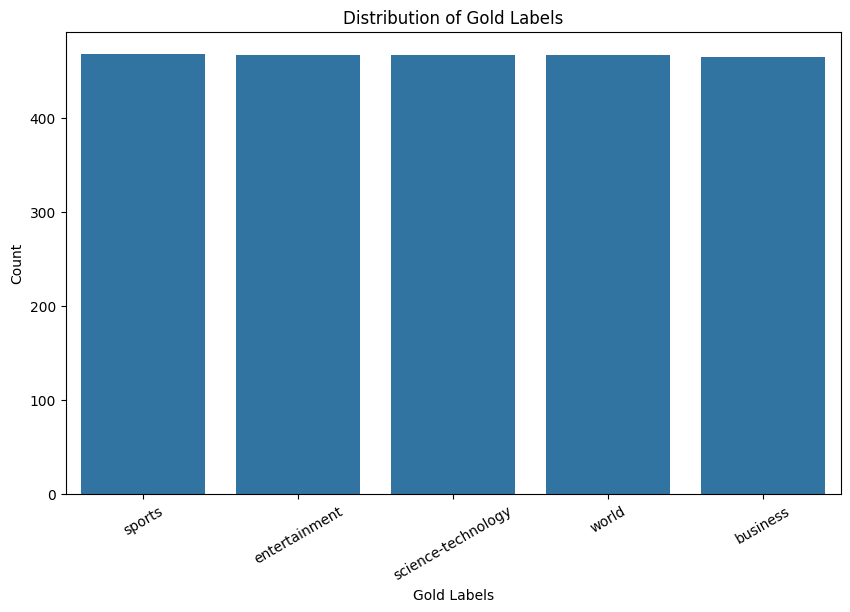

In [57]:
plt.figure(figsize=(10, 6))
sns.countplot(x='gold_label', data=df,
              order=df['gold_label'].value_counts().index)
plt.title('Distribution of Gold Labels')
plt.xlabel('Gold Labels')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

In [58]:
df['gold_label'].unique()

array(['entertainment', 'business', 'sports', 'science-technology',
       'world'], dtype=object)

In [59]:
df['gold_label'] = df['gold_label'].str.strip()

In [60]:
df['title_length'] = df['title'].apply(len)
df['title_length'].describe()

count    2332.000000
mean       62.458834
std        13.666071
min        20.000000
25%        53.000000
50%        62.000000
75%        72.000000
max       123.000000
Name: title_length, dtype: float64

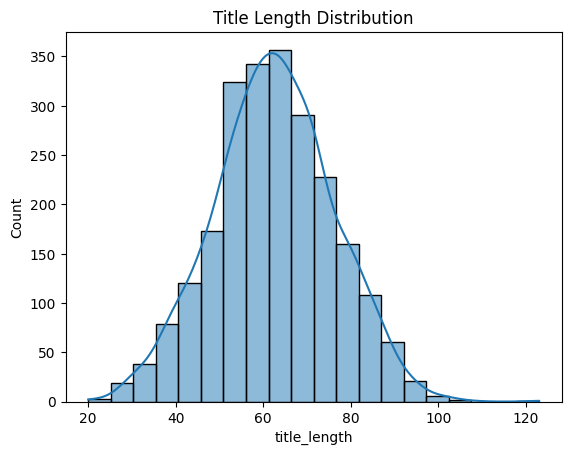

In [61]:
sns.histplot(df['title_length'], bins=20, kde=True)
plt.title('Title Length Distribution')
plt.show()

In [62]:
vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=20)
bow_matrix = vectorizer.fit_transform(df['title'].fillna(''))
print(vectorizer.get_feature_names_out())

['ئی' 'اور' 'بھارتی' 'دیا' 'سی' 'سے' 'میں' 'نے' 'ٹرمپ' 'پاکستان' 'پر' 'پی'
 'کا' 'کر' 'کرنے' 'کو' 'کی' 'کیلئے' 'کے' 'ہے']


In [63]:
df['content'] = df['content'].fillna('')
df['content_length'] = df['content'].apply(len)
df['content_length'].describe()

count     2332.000000
mean      1052.078045
std        698.857259
min          0.000000
25%        652.750000
50%        915.500000
75%       1264.000000
max      10332.000000
Name: content_length, dtype: float64

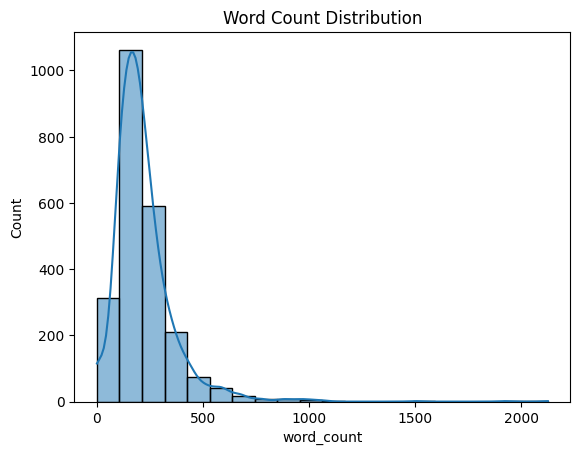

In [64]:
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))
sns.histplot(df['word_count'], bins=20, kde=True)
plt.title('Word Count Distribution')
plt.show()

In [65]:
df[df['content_length'] < 50]

,id,title,link,content,gold_label,title_length,content_length,word_count
171,171,قیمتوں میں بڑی کمی کے بعد سونا آج پھر مہنگا ہوگیا,https://www.express.pk/story/2732955/gold-pric...,,business,49,0,0
178,178,اسٹیٹ بینک نے فنکا مائیکروفنانس بینک کے شیئرز ...,https://www.express.pk/story/2732806/state-ban...,,business,69,0,0
183,183,سونے کی عالمی اور مقامی مارکیٹوں میں قیمت میں ...,https://www.express.pk/story/2732765/gold-pric...,,business,60,0,0
192,192,سونے کی عالمی اور مقامی مارکیٹوں میں قیمت کم ہ...,https://www.express.pk/story/2732572/gold-pric...,,business,51,0,0
195,195,اسٹاک ایکسچینج میں زبردست تیزی؛ انڈیکس 94 ہزار...,https://www.express.pk/story/2732517/stock-exc...,,business,72,0,0
...,...,...,...,...,...,...,...,...
559,559,26 قومی کرکٹرز ایبٹ آباد میں شیڈول ٹریننگ کیمپ...,https://www.express.pk/story/1305371/26qwmy-kr...,,science-technology,54,0,0
575,575,اسرائیل غزہ میں انسانی حقوق سے متعلق سنگین خدش...,https://www.express.pk/story/2733111/eu-foreig...,,world,94,0,0
615,615,مقبوضہ کشمیر میں بھارتی فوج پر حملہ؛ ایک افسر ...,https://www.express.pk/story/2732543/attack-on...,,world,68,0,0
637,637,جونا گڑھ پر بھارت کے غاصبانہ قبضے کو 77 سال مکمل,https://www.express.pk/story/2732266/junagadh-...,,world,48,0,0


DATA CLEANING


In [66]:
df.drop(columns=['link'], inplace=True)

In [67]:
df = df[df['title'].notna() | df['content'].notna()]

In [68]:
def clean_text(text):
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['title'] = df['title'].apply(clean_text)
df['content'] = df['content'].apply(clean_text)

Tokenization and Bag of Words


In [69]:
nlp = spacy.blank('ur')


def tokenize_text(text):
    if pd.isna(text):
        return []
    doc = nlp(text)
    return [token.text for token in doc]


df['title_tokens'] = df['title'].apply(tokenize_text)
df['content_tokens'] = df['content'].apply(tokenize_text)
df[['title', 'title_tokens', 'content', 'content_tokens']].head()

,title,title_tokens,content,content_tokens
0,نیٹ فلکس ڈاؤن سوشل میڈیا پر شکایتوں کا طوفان اگیا,"[نیٹ, فلکس, ڈاؤن, سوشل, میڈیا, پر, شکایتوں, کا...",معروف امریکی اسٹریمنگ پلیٹ فارم نیٹ فلکس باکسن...,"[معروف, امریکی, اسٹریمنگ, پلیٹ, فارم, نیٹ, فلک..."
1,پاکستانی ویب سیریز فروٹ چاٹ کی شوٹنگ کا اغاز ک...,"[پاکستانی, ویب, سیریز, فروٹ, چاٹ, کی, شوٹنگ, ک...",عالمی ایوارڈ یافتہ پاکستان شوبز کے نوجوان ہدای...,"[عالمی, ایوارڈ, یافتہ, پاکستان, شوبز, کے, نوجو..."
2,ریاض میں رنگارنگ فیشن شو جینیفر لوپیز سمیت دیگ...,"[ریاض, میں, رنگارنگ, فیشن, شو, جینیفر, لوپیز, ...",سعودی عرب کےدارالحکومتریاض میں منعقد ہونے والے...,"[سعودی, عرب, کےدارالحکومتریاض, میں, منعقد, ہون..."
3,دیشا پٹانی کے والد کے ساتھ لاکھوں روپے کا فراڈ...,"[دیشا, پٹانی, کے, والد, کے, ساتھ, لاکھوں, روپے...",بالی ووڈ کی خوبرو اداکارہ دیشا پٹانی کے والد ر...,"[بالی, ووڈ, کی, خوبرو, اداکارہ, دیشا, پٹانی, ک..."
4,ڈان میں ولن کون ہوگا نام سامنے اگیا,"[ڈان, میں, ولن, کون, ہوگا, نام, سامنے, اگیا]",بالی ووڈ کی مشہور فلم ڈان فرنچائز کی تیسری فلم...,"[بالی, ووڈ, کی, مشہور, فلم, ڈان, فرنچائز, کی, ..."


In [70]:
class BagOfWords:
    def __init__(self):
        self.vocab = {}

    def fit(self, documents):
        unique_words = set(word for doc in documents for word in doc)
        self.vocab = {word: idx for idx, word in enumerate(unique_words)}

    def transform(self, documents):
        rows = []
        for doc in documents:
            word_counts = Counter(doc)
            row = [word_counts.get(word, 0) for word in self.vocab]
            rows.append(row)
        return np.array(rows)


bow = BagOfWords()
bow.fit(df['title_tokens'] + df['content_tokens'])
X = bow.transform(df['title_tokens'] + df['content_tokens'])

Train Test Split and Label Encoding


In [71]:
le = LabelEncoder()
y = le.fit_transform(df['gold_label'])

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69)

print("Training Data")
print(X_train.shape)
print(y_train.shape)

print("Testing Data")
print(X_test.shape)
print(y_test.shape)

Training Data
(1865, 21173)
(1865,)
Testing Data
(467, 21173)
(467,)


Multinomial Naive Bayes from Scratch


In [73]:
class NaiveBayes:
    def __init__(self):
        self.class_probs = {}
        self.word_probs = {}
        self.vocab_size = 0
        self.classes = []

    def fit(self, X, y):
        n_docs, total_words = X.shape
        self.vocab_size = total_words
        class_word_counts = {}
        class_counts = {}
        for class_index in np.unique(y):
            temp_class = X[y == class_index]
            class_counts[class_index] = len(temp_class)
            class_word_counts[class_index] = np.sum(temp_class, axis=0)
        self.classes = np.unique(y)
        for class_index in self.classes:
            self.class_probs[class_index] = np.log(
                class_counts[class_index] / n_docs)
        for class_index in self.classes:
            total_words_in_class = np.sum(class_word_counts[class_index])
            self.word_probs[class_index] = np.log(
                (class_word_counts[class_index] + 1) / (total_words_in_class + self.vocab_size))

    def predict(self, X):
        predictions = []
        for doc in X:
            class_scores = {}
            for class_index in self.classes:
                class_scores[class_index] = self.class_probs[class_index]
                class_scores[class_index] += np.sum(
                    doc * self.word_probs[class_index])
            predicted_class = max(class_scores, key=class_scores.get)
            predictions.append(predicted_class)
        return np.array(predictions)

Accuracy: 0.9400428265524625
Precision: 0.9402697958833599
Recall: 0.9405293518181562
F1 Score: 0.9399537168332908

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       106
           1       0.92      0.99      0.95        84
           2       0.94      0.94      0.94        95
           3       1.00      0.94      0.97        90
           4       0.86      0.88      0.87        92

    accuracy                           0.94       467
   macro avg       0.94      0.94      0.94       467
weighted avg       0.94      0.94      0.94       467



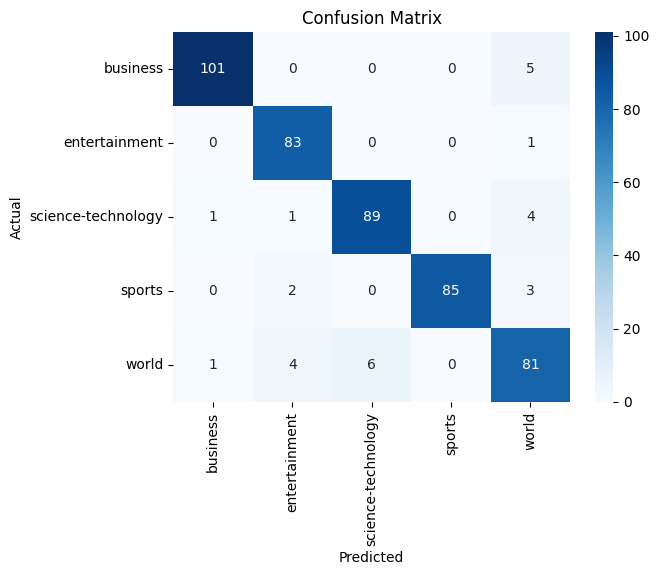

In [74]:
nb = NaiveBayes()
nb.fit(X_train, y_train)
y_test_pred = nb.predict(X_test)
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy: {accuracy}")
precision = precision_score(y_test, y_test_pred, average='macro')
recall = recall_score(y_test, y_test_pred, average='macro')
f1 = f1_score(y_test, y_test_pred, average='macro')
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=[
      str(label) for label in np.unique(y_test)]))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Sklearn Naive Bayes to verify


In [75]:
model = BernoulliNB()
model.fit(X_train, y_train)
y_pred_new = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_new)
print("Bernoulli Implemenation\n")
print("Accuracy:", accuracy)
print("\n")
model2 = MultinomialNB()
model2.fit(X_train, y_train)
y_pred_new = model2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_new)
print("Multinomial Implemenation\n")
print("Accuracy:", accuracy)

Bernoulli Implemenation

Accuracy: 0.9250535331905781


Multinomial Implemenation

Accuracy: 0.9400428265524625
